In [2]:
%load_ext autoreload
%autoreload 2

import os, sys
import glob
import json
import re

import numpy as np
import pandas as pd

import seaborn as sns
from matplotlib import pyplot as plt


sys.path.append('/dartfs/rc/lab/F/FinnLab/tommy/isc_asynchrony_behavior/code/utils/')

from config import *
# import analysis_utils as utils
# import plotting_utils as utils
from tommy_utils import nlp


Token will not been saved to git credential helper. Pass `add_to_git_credential=True` if you want to set the git credential as well.
Token is valid (permission: write).
Your token has been saved to /dartfs/rc/lab/F/FinnLab/tommy/models/token
Login successful


### Load data

In [3]:
window_size = 25

preproc_dir = os.path.join(BASE_DIR, 'stimuli/preprocessed')
results_dir = os.path.join(BASE_DIR, 'derivatives/results/behavioral/')
models_dir = os.path.join(BASE_DIR, 'derivatives/model-predictions/')

results_fn = os.path.join(results_dir, f'all-task_group-analyzed-behavior_window-size-{str(window_size).zfill(5)}_human-model-distributions-lemmatized.csv')

df_results = pd.read_csv(results_fn)

### Extract word information

Average across models and calculate improvement slopes

In [4]:
def calculate_improvement_slopes(df_results, average_models=True):
    """
    Calculate improvement slopes across modalities for each word.
    
    Parameters:
    -----------
    df_results : pd.DataFrame
        Results dataframe with columns: modality, task, word_index, model_name, human_model_accuracy_diff
    average_models : bool, default True
        If True, average across all models before calculating slopes.
        If False, calculate separate slopes for each model.
    
    Returns:
    --------
    pd.DataFrame
        DataFrame with improvement slopes and additional word information
    """
    # Put models as columns and modality, task, word_index as rows
    df = pd.pivot(df_results, index=['modality', 'task', 'word_index'], columns='model_name', values='human_model_accuracy_diff')
    
    # Get the additional columns we want to keep
    cols_to_keep = ['prominence_mean_words5', 'POS_spaCy', 'Dep', 'Head', 'Clause_ID', 'Clause_Pos', 'ground_truth']
    additional_cols = df_results.groupby(['task', 'word_index'])[cols_to_keep].first().reset_index()
    
    if average_models:
        # Average over all models for each modality/task/word
        df = df.mean(axis=1).reset_index().rename(columns={0: 'accuracy_diff'})
        
        # Group by task and word_index
        df_grouped = df.groupby(['task', 'word_index'])
        
        # Calculate slope for each word across modalities
        slopes = []
        for (task, word_idx), group in df_grouped:
            # Get values in order text -> audio -> video (assumed progression)
            modality_order = ['text', 'audio', 'video']
            y = [group[group['modality']==m]['accuracy_diff'].iloc[0] for m in modality_order]
            x = np.arange(len(modality_order))
            
            # Fit slope using numpy polyfit
            slope = np.polyfit(x, y, 1)[0]
            slopes.append({
                'task': task,
                'word_index': word_idx,
                'improvement_slope': slope,
                'text_acc': y[0],
                'audio_acc': y[1], 
                'video_acc': y[2]
            })
        
        # Convert to dataframe and merge with additional columns
        df_slopes = pd.DataFrame(slopes)
        df_slopes = df_slopes.merge(additional_cols, on=['task', 'word_index'])
        
    else:
        # Calculate separate slopes for each model
        df = df.reset_index()
        
        # Group by task, word_index, and model
        slopes = []
        for task in df['task'].unique():
            for word_idx in df['word_index'].unique():
                for model in df.columns[3:]:  # Skip modality, task, word_index columns
                    task_word_data = df[(df['task'] == task) & (df['word_index'] == word_idx)]
                    if len(task_word_data) == 3:  # Make sure we have all three modalities
                        # Get values in order text -> audio -> video (assumed progression)
                        modality_order = ['text', 'audio', 'video']
                        y = []
                        for modality in modality_order:
                            val = task_word_data[task_word_data['modality'] == modality][model].iloc[0]
                            if not pd.isna(val):
                                y.append(val)
                            else:
                                y.append(0)  # Handle NaN values
                        
                        x = np.arange(len(modality_order))
                        
                        # Fit slope using numpy polyfit
                        slope = np.polyfit(x, y, 1)[0]
                        slopes.append({
                            'task': task,
                            'word_index': word_idx,
                            'model_name': model,
                            'improvement_slope': slope,
                            'text_acc': y[0],
                            'audio_acc': y[1], 
                            'video_acc': y[2]
                        })
        
        # Convert to dataframe and merge with additional columns
        df_slopes = pd.DataFrame(slopes)
        df_slopes = df_slopes.merge(additional_cols, on=['task', 'word_index'])
    
    return df_slopes

In [5]:
# Calculate slopes (averaging across models by default)
df = calculate_improvement_slopes(df_results, average_models=True)

### Get contexts and features for each predicted word

In [7]:
def add_word_features(df, text_col="ground_truth"):
    import numpy as np
    from pliers.stimuli import TextStim
    from pliers.extractors import PredefinedDictionaryExtractor, VADERSentimentExtractor, merge_results

    # Build stimuli
    stims = [TextStim(text=word.lower(), order=i) for i, word in enumerate(df[text_col])]

    # Extractors
    freq_ext = PredefinedDictionaryExtractor(['subtlexusfrequency/Lg10WF'], missing=np.nan)
    valence_arousal_ext = PredefinedDictionaryExtractor(['affect/V.Mean.Sum', 'affect/A.Mean.Sum'], missing=np.nan)
    concreteness_ext = PredefinedDictionaryExtractor(['concreteness/Conc.M'], missing=np.nan)

    # Apply extractors
    freq_res = freq_ext.transform(stims)
    valence_res = valence_arousal_ext.transform(stims)
    concreteness_res = concreteness_ext.transform(stims)

    # Merge into one dataframe
    df_results = merge_results([freq_res, valence_res, concreteness_res],
                               extractor_names='column', format='wide')

    # return df_results
    # Make a copy of original df
    df_out = df.copy()

    # return df_results

    # Grab the indices of the words that were processed
    idxs = df_results['order'].values
    df_out.loc[idxs, ['Frequency', 'Valence', 'Arousal', 'Concreteness']] = df_results[['subtlexusfrequency_Lg10WF', 'affect_V.Mean.Sum', 'affect_A.Mean.Sum', 'concreteness_Conc.M']].values

    # Manually calculate word length
    df_out["Length"] = df[text_col].str.len()

    return df_out


# For each NWP candidate word, get 5 words before as context
def get_context(df, n_prev_words=5):
    # Get indices of NWP candidates
    nwp_indices = df[df['NWP_Candidate']].index
    
    contexts = []
    for idx in nwp_indices:
        # Get up to 5 words before the current word
        start_idx = max(0, idx - n_prev_words)
        context_words = df.iloc[start_idx:idx]['Word_Written'].tolist()
        target_word = df.iloc[idx]['Word_Written']
        
        # Join context words and target word
        context = ' '.join(context_words + [target_word])
        contexts.append(context)
    
    # Add context column for NWP candidates
    df.loc[nwp_indices, 'context'] = contexts
    df = df.loc[nwp_indices]
    
    return df

Run for each task

In [9]:
# Add sentiment analysis
from tqdm import tqdm
from transformers import pipeline

df_contexts = []
tasks = df['task'].unique()

# Load sentiment analysis pipeline
sentiment_analyzer = pipeline("sentiment-analysis", model="tabularisai/multilingual-sentiment-analysis")

for task in tasks:
    # Get transcript
    df_transcript = pd.read_csv(os.path.join(preproc_dir, task, f'{task}_transcript-selected.csv')) 
    # df_transcript['task'] = task

    df_context = get_context(df_transcript)
    df_context['task'] = task
    
    # Store the original index from transcript as word_index for merging
    df_context = df_context.reset_index()
    df_context = df_context.rename(columns={'index': 'word_index'})

    # Apply sentiment analysis to each context
    results = []
    for text in tqdm(df_context['context'], desc=f"Sentiment analysis for {task}"):
        result = sentiment_analyzer(text)
        results.append(result[0])  # Get first element since pipeline returns list of dicts
    
    # Add word features directly here
    df_context = add_word_features(df_context, text_col="Word_Written")
    
    # Convert results to DataFrame columns
    df_context['sentiment_label'] = [r['label'] for r in results]
    df_context['sentiment_score'] = [r['score'] for r in results]
    
    df_contexts.append(df_context)

df_contexts = pd.concat(df_contexts, ignore_index=True)

# Merge context and features into df based on task and word_index
merge_cols = ['task', 'word_index', 'context', 'Frequency', 'Valence', 'Arousal', 'Concreteness', 'Length', 'sentiment_label', 'sentiment_score']
df = df.merge(df_contexts[merge_cols], on=['task', 'word_index'], how='left')

2025-09-23 11:17:41.281910: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
/dartfs/rc/lab/F/FinnLab/tommy/conda/envs/dark_matter/lib/python3.9/site-packages/transformers/utils/generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
Sentiment analysis for black: 100%|██████████| 194/194 [04:48<00:00,  1.49s/it]
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can 

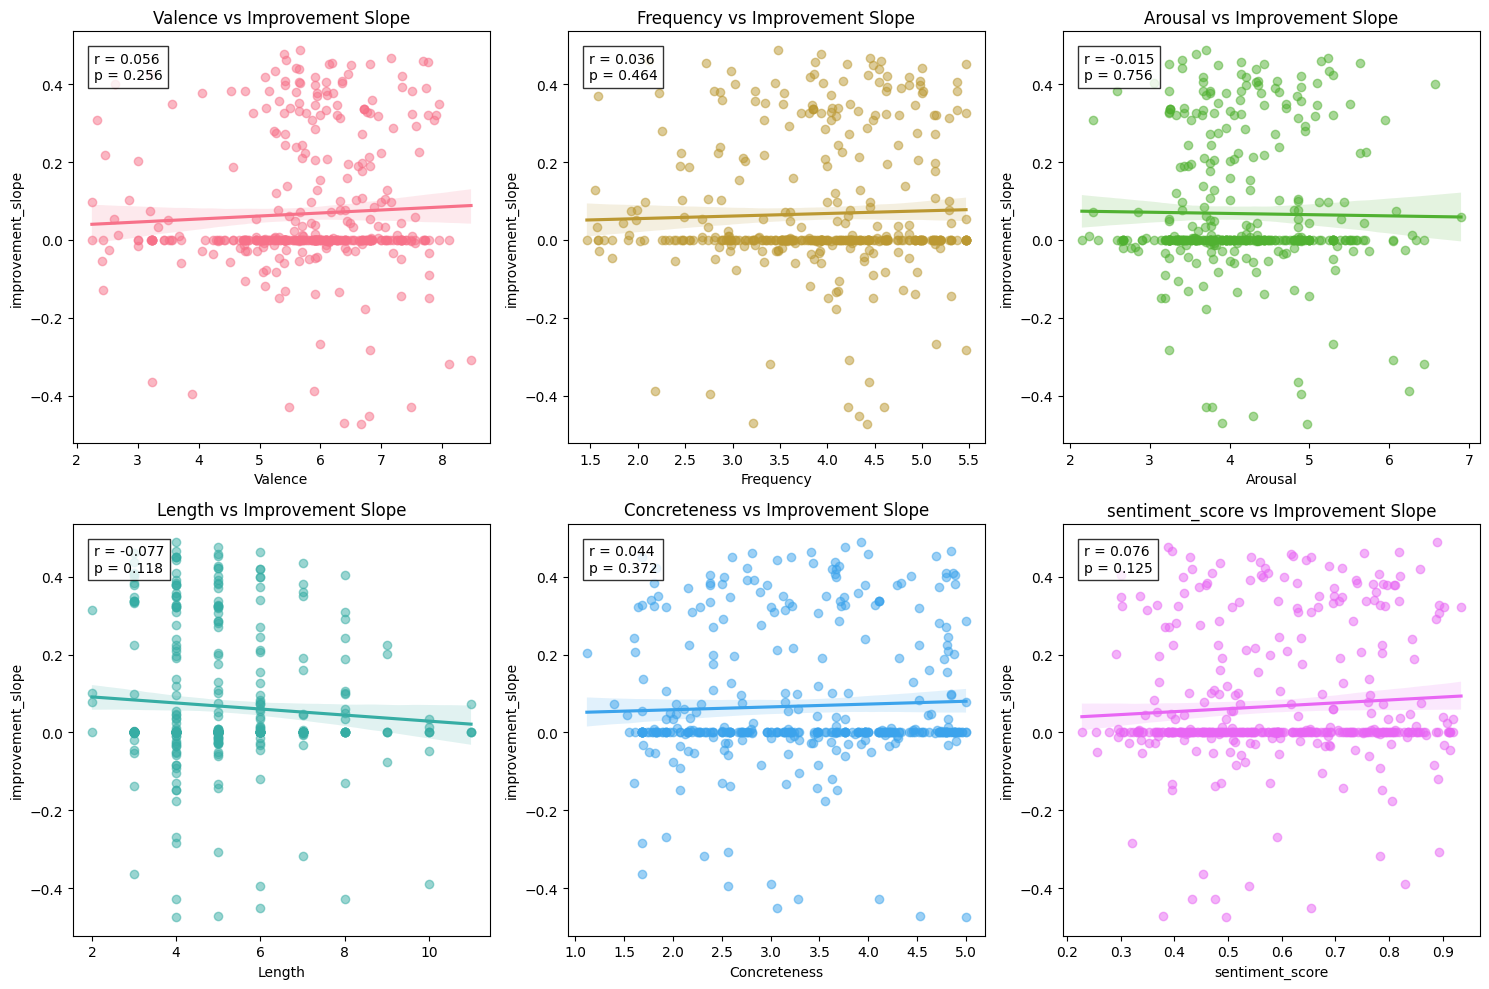

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

df_features = df.copy()
df_features.dropna(inplace=True)

# Set up the figure and axes
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

# Create subplots for each feature
features_to_compare = ['Valence', 'Frequency', 'Arousal', 'Length', 'Concreteness', 'sentiment_score']
colors = sns.color_palette("husl", len(features_to_compare))

for idx, (feature, color, ax) in enumerate(zip(features_to_compare, colors, axes)):
    # Calculate Pearson correlation
    r, p = stats.pearsonr(df_features[feature], df_features['improvement_slope'])
    
    # Create scatter plot with regression line
    sns.regplot(data=df_features,
                x=feature,
                y='improvement_slope',
                scatter_kws={'alpha':0.5, 'color': color},
                line_kws={'color': color},
                ax=ax)
    
    # Add correlation stats to plot
    ax.text(0.05, 0.95, f'r = {r:.3f}\np = {p:.3f}',
            transform=ax.transAxes,
            verticalalignment='top',
            bbox=dict(facecolor='white', alpha=0.8))
    
    ax.set_title(f'{feature} vs Improvement Slope')

# Remove the empty subplot
if len(axes) > len(features_to_compare):
    fig.delaxes(axes[-1])

plt.tight_layout()

In [ ]:
df.to_csv(
    os.path.join(results_dir, f'exploratory-features-analysis.csv'), index=False
)

In [16]:
df.head().columns

Index(['task', 'word_index', 'improvement_slope', 'text_acc', 'audio_acc',
       'video_acc', 'prominence_mean_words5', 'POS_spaCy', 'Dep', 'Head',
       'Clause_ID', 'Clause_Pos', 'ground_truth', 'context', 'Frequency',
       'Valence', 'Arousal', 'Concreteness', 'Length', 'sentiment_label',
       'sentiment_score'],
      dtype='object')

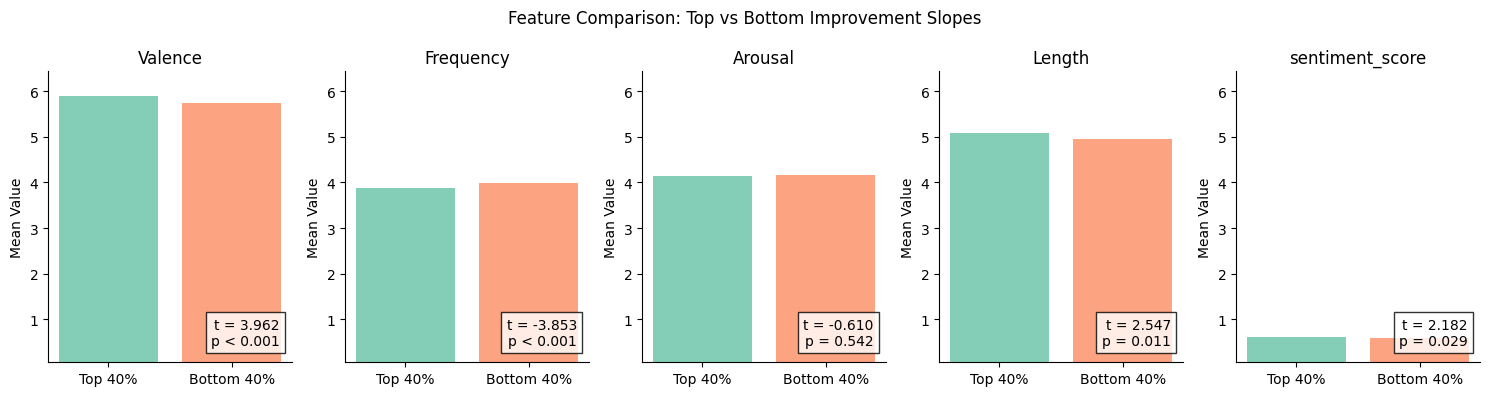

In [36]:
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt

df_features.dropna(inplace=True)

# Get top and bottom 30% of slopes
n_words = len(df_features)
n_subset = int(n_words * 0.40)

top_slopes = df_features.nlargest(n_subset, 'improvement_slope')
bottom_slopes = df_features.nsmallest(n_subset, 'improvement_slope')

# Compare features between groups
features_to_compare = ['Valence', 'Frequency', 'Arousal', 'Length', 'sentiment_score']

# Set up the figure and axes for bar plots
fig, axes = plt.subplots(1, len(features_to_compare), figsize=(15, 4))
colors = sns.color_palette("Set2", 2)  # Pretty colors

# Calculate global y limits
all_means = []
for feature in features_to_compare:
    all_means.extend([top_slopes[feature].mean(), bottom_slopes[feature].mean()])
y_min, y_max = min(all_means), max(all_means)
y_range = y_max - y_min
y_bottom = y_min - 0.1 * y_range
y_top = y_max + 0.1 * y_range

for idx, feature in enumerate(features_to_compare):
    t_stat, p_val = stats.ttest_ind(top_slopes[feature], bottom_slopes[feature])
    
    # Create bar plot
    means = [top_slopes[feature].mean(), bottom_slopes[feature].mean()]
    labels = ['Top 40%', 'Bottom 40%']
    
    bars = axes[idx].bar(labels, means, color=colors, alpha=0.8)
    axes[idx].set_title(f'{feature}')
    axes[idx].set_ylabel('Mean Value')
    axes[idx].set_ylim(y_bottom, y_top)
    
    # Despine the plot
    sns.despine(ax=axes[idx])
    
    # Add t and p-value annotation on bottom right
    if p_val < 0.001:
        p_text = 'p < 0.001'
    else:
        p_text = f'p = {p_val:.3f}'
    
    axes[idx].text(0.95, 0.05, f't = {t_stat:.3f}\n{p_text}', 
                   ha='right', va='bottom', fontsize=10,
                   transform=axes[idx].transAxes,
                   bbox=dict(facecolor='white', alpha=0.8))

plt.suptitle('Feature Comparison: Top vs Bottom Improvement Slopes')
plt.tight_layout()
plt.show()

Plot slopes and average slope line

Text(0.5, 1.0, 'Improvement Slopes Across Modalities')

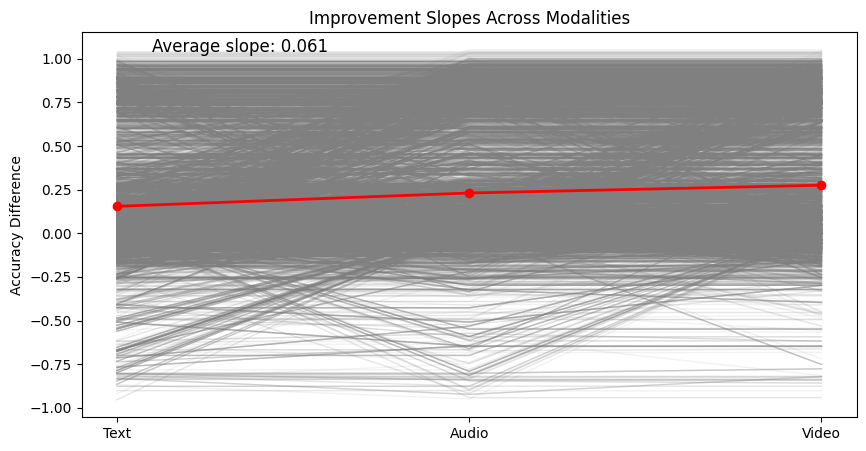

In [37]:
# Plot raw values and improvement slopes
plt.figure(figsize=(10,5))

# Plot individual points and lines for each word
for _, row in df.iterrows():
    values = [row.text_acc, row.audio_acc, row.video_acc]
    # if len(set(values)) > 1:  # Only plot if values are not all equal
    plt.plot([0,1,2], values, color='gray', alpha=0.1, linewidth=1)

# Plot mean values
mean_values = [df.text_acc.mean(), df.audio_acc.mean(), df.video_acc.mean()]
plt.plot([0,1,2], mean_values, color='red', linewidth=2, marker='o')

# Calculate and plot average slope
x = np.array([0,1,2])
y = np.array(mean_values)
slope = np.polyfit(x, y, 1)[0]
plt.text(0.1, plt.ylim()[1]*0.9, f'Average slope: {slope:.3f}', fontsize=12)

plt.xticks([0,1,2], ['Text', 'Audio', 'Video'])
plt.ylabel('Accuracy Difference')
plt.title('Improvement Slopes Across Modalities')

### Extract word statistics

### POS classification

Classification accuracy: 0.304

Classification Report:
              precision    recall  f1-score   support

    Modifier       0.12      0.11      0.11        28
     Nominal       0.35      0.59      0.44        51
       Other       0.00      0.00      0.00         0
        Verb       0.35      0.14      0.20        56

    accuracy                           0.30       135
   macro avg       0.20      0.21      0.19       135
weighted avg       0.30      0.30      0.27       135



/dartfs/rc/lab/F/FinnLab/tommy/conda/envs/asynchrony/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/dartfs/rc/lab/F/FinnLab/tommy/conda/envs/asynchrony/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/dartfs/rc/lab/F/FinnLab/tommy/conda/envs/asynchrony/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average,

,task,word_index,improvement_slope,text_acc,audio_acc,video_acc,POS_spaCy,Dep,Head,Clause_ID,Clause_Pos,ground_truth,POS_collapsed
0,black,6,1.598253e-01,0.303070,0.622720,0.622720,NOUN,pobj,in,1,7,college,Nominal
1,black,12,-8.795718e-02,0.023717,0.023717,-0.152197,VERB,amod,job,3,2,pay,Verb
2,black,19,2.235533e-03,0.050851,0.055322,0.055322,NOUN,pobj,on,2,11,radio,Nominal
3,black,24,-3.884748e-01,0.971510,0.150529,0.194560,NOUN,attr,is,4,5,internship,Nominal
4,black,32,-6.310164e-03,-0.007034,-0.019655,-0.019655,NOUN,attr,was,5,4,country,Nominal
...,...,...,...,...,...,...,...,...,...,...,...,...,...
667,wheretheressmoke,1738,3.781434e-01,0.021749,0.021749,0.778036,NOUN,pobj,of,322,9,gas,Nominal
668,wheretheressmoke,1745,-4.739281e-01,0.814748,-0.133109,-0.133109,NOUN,dobj,have,323,7,baby,Nominal
669,wheretheressmoke,1758,3.250779e-01,0.057946,0.708102,0.708102,NUM,nummod,cigarettes,327,4,seven,Nominal
670,wheretheressmoke,1783,-4.694853e-02,0.012994,0.012994,-0.080903,VERB,conj,had,333,1,hold,Verb


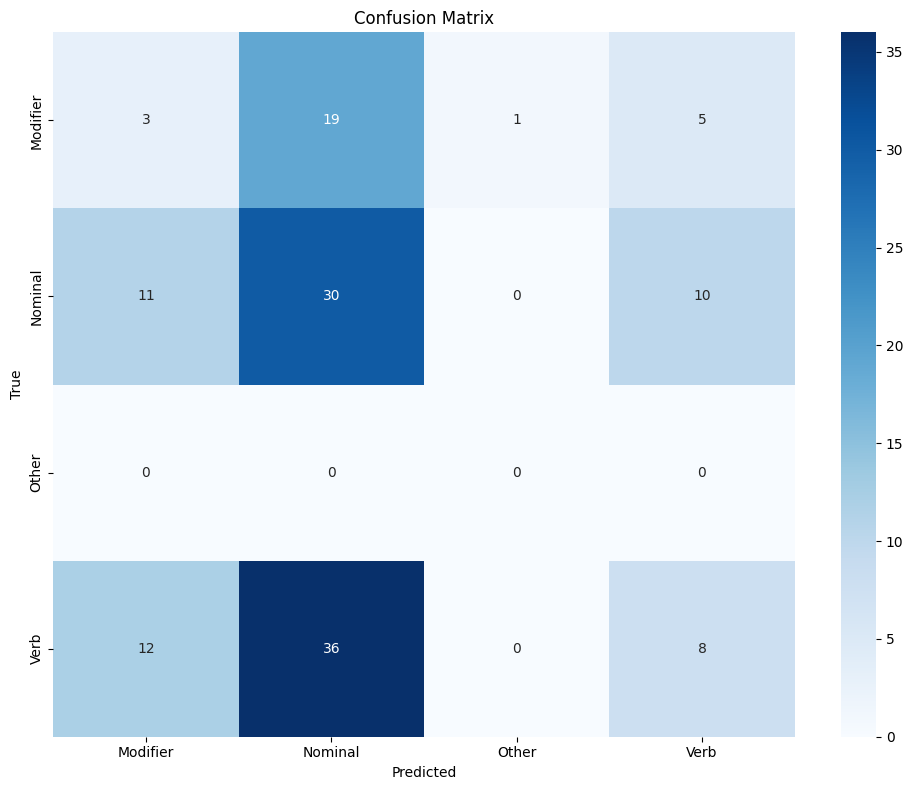

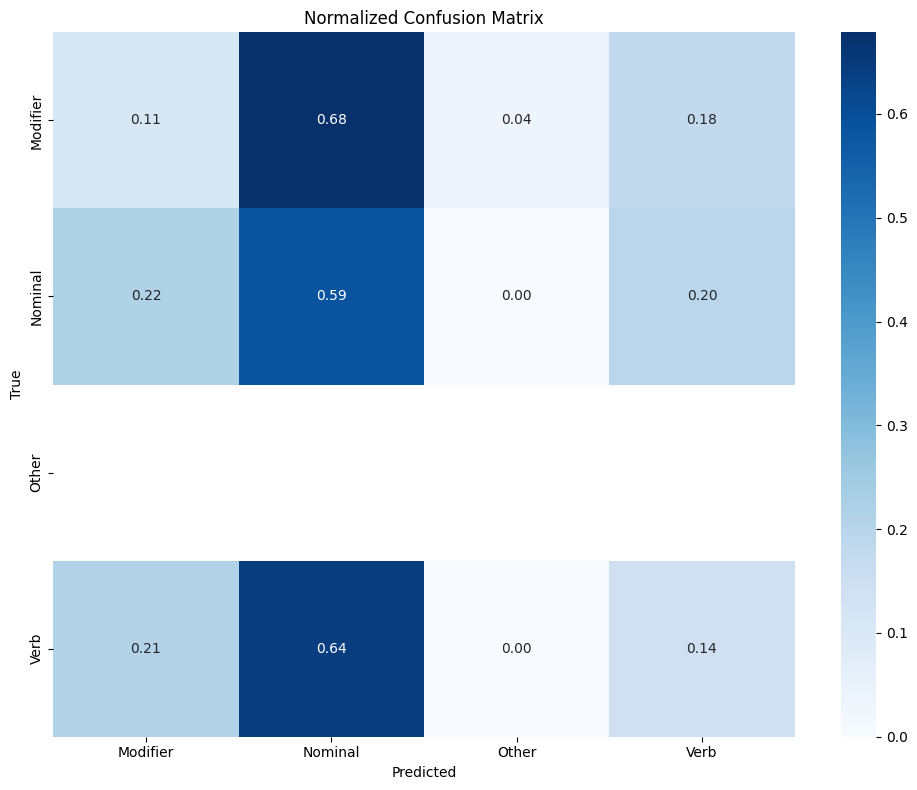

In [42]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

# Create collapsed POS categories
def collapse_pos(pos):
    if pos in ['NOUN', 'PROPN', 'PRON', 'NUM']:
        return 'Nominal'
    elif pos in ['VERB', 'AUX']:
        return 'Verb'
    elif pos in ['ADJ', 'ADV']:
        return 'Modifier'
    else:
        return 'Other'

df['POS_collapsed'] = df['POS_spaCy'].apply(collapse_pos)

# Prepare data for POS classification
X = df['improvement_slope'].values.reshape(-1, 1)
y = df['POS_collapsed'].values

# Split into train/test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a simple classifier
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_train)

# Get predictions and accuracy
y_pred = clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"Classification accuracy: {accuracy:.3f}")

# Show classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)
labels = sorted(list(set(y)))

# Plot confusion matrix
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels,
            yticklabels=labels)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()

# Plot normalized confusion matrix
plt.figure(figsize=(10,8))
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=labels,
            yticklabels=labels)
plt.title('Normalized Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()

# Show original dataframe with predictions and collapsed categories
df

### Add in pliers features

In [ ]:
df_results

Signature:
df_results.melt(
    id_vars=None,
    value_vars=None,
    var_name=None,
    value_name='value',
    col_level=None,
    ignore_index=True,
) -> 'DataFrame'
Docstring:
Unpivot a DataFrame from wide to long format, optionally leaving identifiers set.

This function is useful to massage a DataFrame into a format where one
or more columns are identifier variables (`id_vars`), while all other
columns, considered measured variables (`value_vars`), are "unpivoted" to
the row axis, leaving just two non-identifier columns, 'variable' and
'value'.

Parameters
----------
id_vars : tuple, list, or ndarray, optional
    Column(s) to use as identifier variables.
value_vars : tuple, list, or ndarray, optional
    Column(s) to unpivot. If not specified, uses all columns that
    are not set as `id_vars`.
var_name : scalar
    Name to use for the 'variable' column. If None it uses
    ``frame.columns.name`` or 'variable'.
value_name : scalar, default 'value'
    Name to use for the 'value

/dartfs/rc/lab/F/FinnLab/tommy/isc_asynchrony_behavior/code/utils/plotting_utils.py:91: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df, x=x, y=y, hue=hue, palette=cmap, alpha=alpha, order=order, hue_order=hue_order, ax=ax)
/dartfs/rc/lab/F/FinnLab/tommy/isc_asynchrony_behavior/code/utils/plotting_utils.py:91: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df, x=x, y=y, hue=hue, palette=cmap, alpha=alpha, order=order, hue_order=hue_order, ax=ax)
/dartfs/rc/lab/F/FinnLab/tommy/isc_asynchrony_behavior/code/utils/plotting_utils.py:91: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` an

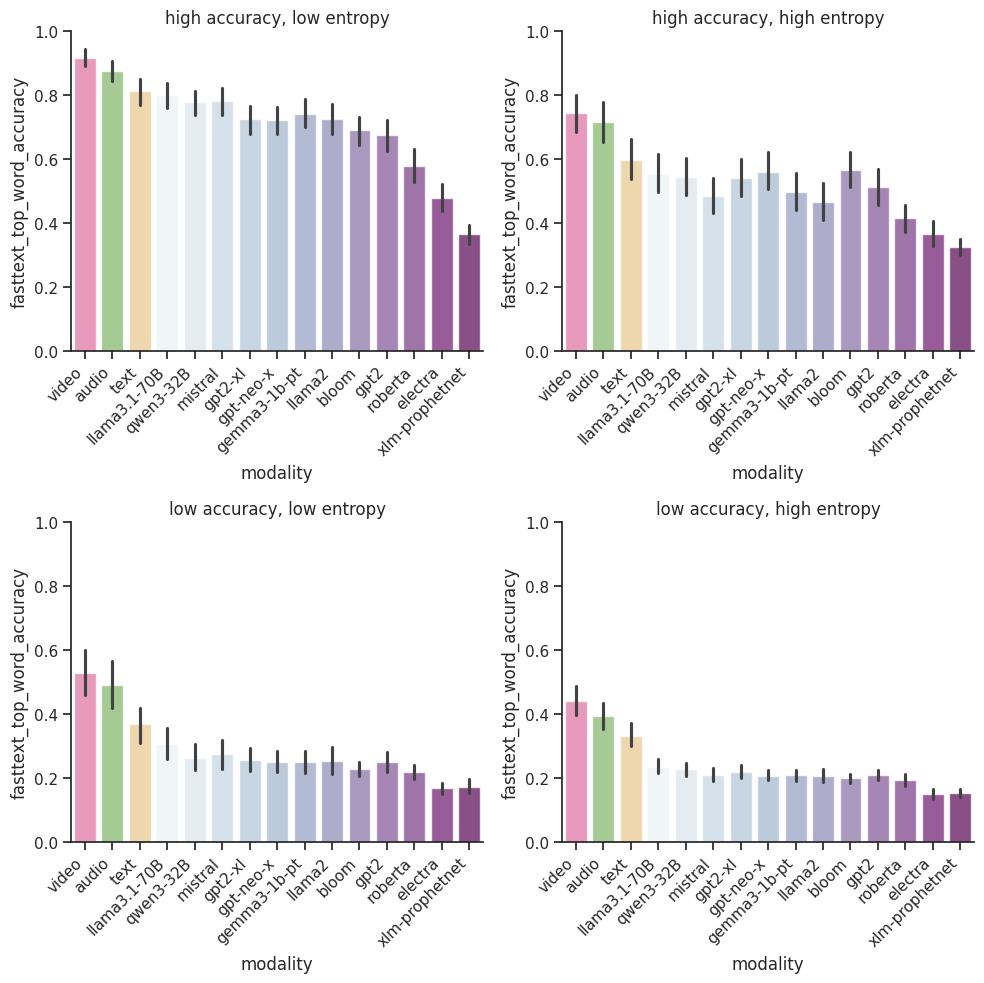

In [65]:
accuracy_entropy_groups = [
    'high-low',
    'high-high',
    'low-low',
    'low-high'
]

variable = 'fasttext_top_word_accuracy'
N_MODELS = len(model_names)

cmap = utils.create_colormap(dtype='multimodal', continuous=False, N_MODELS=N_MODELS)

fig, axes = plt.subplots(2,2, figsize=(10,10))
axes = axes.flatten()

for ax, group in zip(axes, accuracy_entropy_groups):

    accuracy_group, entropy_group = group.split('-')

    accuracy_mask = df_results['accuracy_group'] == accuracy_group
    entropy_mask = df_results['entropy_group'] == entropy_group
    df_group = df_results[accuracy_mask & entropy_mask]

    utils.plot_bar_results(df_group, x='modality', y=variable, hue=None, order=human_models_order, cmap=cmap, figsize=None, add_points=False, ax=ax)
    ax.set_ylim([0, 1])
    # ax.set_title(f'Task - {task}')
    # plt.xticks(rotation=45, ha='right')
    # Rotate x-axis labels for this axis
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
        
    # sns.barplot(df_group, x='modality', y='fasttext_top_word_accuracy',  ax=ax, order=human_models_order)
    ax.set_title(f'{accuracy_group} accuracy, {entropy_group} entropy')
    # ax.set_xlabel('Average Accuracy')
    ax.set_ylabel(variable)
    sns.despine()

plt.tight_layout()

In [61]:
# Set window sizes
WINDOW_SIZES = [
    2, 3, 4, 5, 10, 25, 50, 75, 100, 125, 150, 175, 200, 225, 250, 275, 300
]

if len(modality_list) == 3:
    CMAP_DTYPE = 'multimodal'
else:
    CMAP_DTYPE = 'spoken-written'

FIG_SIZE = (5, 4)

preproc_dir = os.path.join(BASE_DIR, 'stimuli/preprocessed')
results_dir = os.path.join(BASE_DIR, 'derivatives/results/behavioral/')

###################################
### Load results from task list ###
###################################

models_dir = os.path.join(BASE_DIR, 'derivatives/model-predictions/')
plots_dir = os.path.join(BASE_DIR, 'derivatives/plots/final/human-llm-comparison/')

MLM_MODELS = list(nlp.MLM_MODELS_DICT.keys())[1:]
CLM_MODELS = list(nlp.CLM_MODELS_DICT.keys()) 
model_names = CLM_MODELS + MLM_MODELS

remove_models = ['qwen3-8B', 'llama3.1-8B']
model_names = [model for model in model_names if model not in remove_models]

# model_names = ['gemma3-1b-pt', 'qwen3-32B', 'llama3.1-70B']


print (f'Loading the following models')
print (f'MLM models: {MLM_MODELS}')
print (f'CLM models: {CLM_MODELS}')

# ###################################
# ### Load results from task list ###
# ###################################

df_results = []

for task in task_list:
    for i, window_size in enumerate(WINDOW_SIZES):
        results_fn = os.path.join(results_dir, f'task-{task}_group-analyzed-behavior_window-size-{str(window_size).zfill(5)}_human-model-lemmatized.csv')

        if os.path.exists(results_fn):
            df_task = pd.read_csv(results_fn)
            df_task['task'] = task
            df_task['window_size'] = window_size
            df_task['window_number'] = i
            df_results.append(df_task)

df_results = pd.concat(df_results).reset_index(drop=True)


Loading the following models
MLM models: ['roberta', 'electra', 'xlm-prophetnet']
CLM models: ['bloom', 'gpt2', 'gpt2-xl', 'gpt-neo-x', 'llama2', 'mistral', 'qwen3-8B', 'qwen3-32B', 'llama3.1-8B', 'llama3.1-70B', 'gemma3-1b-pt']


/scratch/f003rjw/ipykernel_2473211/4136850024.py:23: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(df_results, x='window_number', y=variable, hue='modality', marker="o", markersize=4, ci=None, palette=cmap, linewidth=2, hue_order=human_models_order)


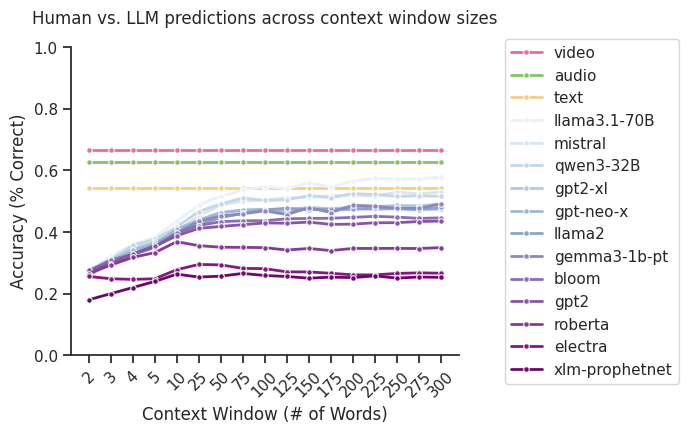

In [62]:
# df_results = pd.concat(df_results).reset_index(drop=True)
# df_results.to_csv(out_fn, index=False)
# df_results = pd.concat(df_results).reset_index(drop=True)

# use the accuracy within these results to get the order to plot the models
ordered_accuracy = utils.get_ordered_accuracy(df_results)

# always put humans first (audio, text) then CLM models, then MLM models
order = modality_list + MLM_MODELS
models_order = [item for item in ordered_accuracy if item not in order]
models_order = models_order + MLM_MODELS

human_models_order = modality_list + models_order

###################################
##### Make line plot of sizes #####
###################################
cmap = utils.create_colormap(dtype=CMAP_DTYPE, continuous=False, N_MODELS=N_MODELS)

sns.set(style='ticks', rc={'figure.figsize': FIG_SIZE})

variable = f'fasttext_top_word_accuracy'
sns.lineplot(df_results, x='window_number', y=variable, hue='modality', marker="o", markersize=4, ci=None, palette=cmap, linewidth=2, hue_order=human_models_order)

# plt.xticks(WINDOW_SIZES)
plt.xticks(range(len(WINDOW_SIZES)), WINDOW_SIZES, rotation=45)

plt.gca().legend(bbox_to_anchor=(1.1, 1.05))
plt.xlabel('Context Window (# of Words)')
plt.ylabel('Accuracy (% Correct)')
plt.ylim([0, 1.0])

# plt.title('Human predictions are more accurate than LLMs regardless of context window', y=1.05)
plt.title("Human vs. LLM predictions across context window sizes", y=1.05)
sns.despine()

/dartfs/rc/lab/F/FinnLab/tommy/isc_asynchrony_behavior/code/utils/plotting_utils.py:498: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.ax_joint.set_xticklabels(x_ticklabels)
/dartfs/rc/lab/F/FinnLab/tommy/isc_asynchrony_behavior/code/utils/plotting_utils.py:503: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.ax_joint.set_yticklabels(y_ticklabels)


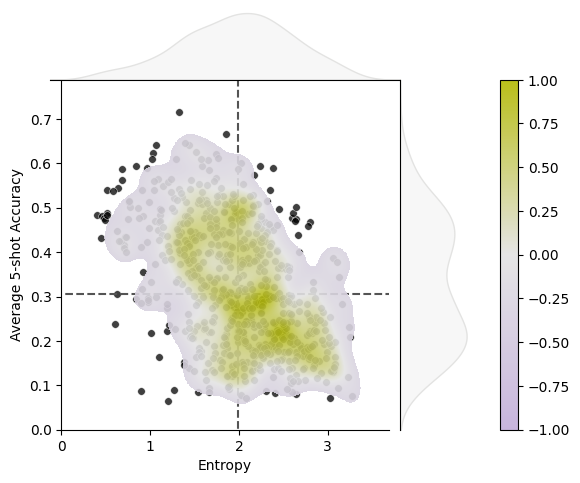

In [ ]:



# Load quadrants across tasks
df_quadrants = utils.load_task_model_quadrants(preproc_dir, models_dir, task_list, model_names, word_model)

# Create the density plot
# cmap = utils.create_colormap(dtype='human-model', continuous=True, N_MODELS=N_MODELS)
g = utils.create_joint_density_plot(df_tasks, df_quadrants, cmap=cmap)

# plt.savefig(os.path.join(plots_dir, "all-task_human-llm-comparison_quadrant-plot.pdf"), bbox_inches='tight', dpi=600)
# plt.close('all')